# train_base_safe

Train `MATD3` with LSTM forecasting (`prediction_mode="normal"`) and safety penalties in the optimization objective.

## Managed LSTM Preset

These MADRL notebooks reuse the managed LSTM artifacts produced by `notebooks/forecast/forecast_lstm.ipynb`. They do not train or refresh forecast models themselves.

This is a full forecast-configuration switch, not just a hidden-size change, so forecast accuracy and downstream training behaviour may change. That is expected.

| Field | Default | Managed preset |
|---|---:|---:|
| `lstm_hidden_size` | `64` | `price/load/pv=64` |
| `lstm_num_layers` | `1` | `price/load=2, pv=1` |
| `lstm_dropout` | `0.0` | `price/load/pv=0.10` |
| `lstm_batch_size` | `512` | `1024` |
| `lstm_epochs` | `4` | `20` |
| `lstm_lr` | `1e-3` | `price/load=1e-3, pv=8e-4` |
| `load_component_split` | `False` | `True` |
| `load_scaler_type` | `"standard"` | `"robust"` |
| `auto_train_missing` | `True` | preset default `False`, kept as `False` here |

If you change `agent_profiles`, `future_horizon`, `history_window`, `load_component_split`, `load_scaler_type`, or the per-signal LSTM overrides, rerun `notebooks/forecast/forecast_lstm.ipynb` before starting MADRL training.


In [1]:
from copy import deepcopy
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root from the notebook working directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import display

from configs.profiles import compose_experiment_config, recommended_gpu_fast_num_envs
from scripts.plots.rollout_plots import plot_voltage_and_net_load_dashboard
from scripts.plots.reward_plots import plot_reward_decomposition
from scripts.mainline_madrl import resolve_madrl_model_root
from predictors.mainline_forecast import get_mainline_forecast_controls
from scripts.utils.grid_notebook_workflow import (
    apply_notebook_experiment_settings,
    normalize_date_input,
    plot_power_balance_comparison,
    plot_rollout_dashboard,
)
from scripts.mainline_compare import collect_madrl_rollout
from predictors.shared_data import build_shared_data_status_summary, ensure_madrl_shared_data
from scripts.utils.project_paths import get_forecast_lstm_notebook_path, project_root
from scripts.mainline_madrl import load_train_mainline_result, run_external_train_mainline



In [ ]:
PROJECT_ROOT = project_root()
DATA_DIR = PROJECT_ROOT / "data"
CHECKPOINT_ROOT = None

force_retrain_madrl = True
algorithm = 'MATD3'
test_start_date = "2020-06-01"  # e.g. "2020-06-01"
test_end_date = "2020-06-05"  # e.g. "2020-06-05"
w_soc_pen = 2
load_scale = [10.0] * 5
pv_scale = [5.0] * 5
battery_capacity_kwh = 20.0
battery_max_power_kw = 10.0
battery_max_charge_rate = battery_max_power_kw / battery_capacity_kwh
notebook_battery_controls = {"battery_capacity": battery_capacity_kwh, "max_charge_rate": battery_max_charge_rate}
w_voltage_pen = 400.0
w_line_pen = 0
w_trafo_pen = 10.0
train_episodes = 500
update_interval = 1
updates_per_step = 4
policy_update_freq = 2
progress_episode_interval = 10
num_envs = 8

REUSE_MODEL_ROOT = None  # Optional explicit run directory when force_retrain_madrl=False

experiment_name = 'train_base_safe'
display_label = 'MADRL + Safety Penalty'
prediction_mode = "normal"


forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
experiment_controls = {
    "algorithm": algorithm,
    "seed": 0,
    "runtime_mode": "performance",
    "device_request": None,
    "require_cuda": False,
    "runtime_controls": {},
    "forecast_controls": forecast_controls,
    "reward_controls": {
        "w_soc_pen": w_soc_pen,
        "w_voltage_pen": w_voltage_pen,
        "w_line_pen": w_line_pen,
        "w_trafo_pen": w_trafo_pen,
    },
}

train_controls = {
    "launch_mode": "external",
    "profile": "gpu_fast",
    "model_family": "mlp",
    "train_episodes": int(train_episodes),
    "max_train_steps": None,
    "num_envs": int(num_envs),
    "vec_env_type": "subproc" if int(num_envs) > 1 else "dummy",
    "parallel_episode_sampling": "unique_active",
    "update_interval": int(update_interval),
    "updates_per_step": int(updates_per_step),
    "policy_update_freq": int(policy_update_freq),
    "show_progress": True,
    "progress_postfix_interval": 10,
    "progress_episode_interval": int(progress_episode_interval),
}

checkpoint_controls = {"experiment_name": experiment_name}
if CHECKPOINT_ROOT is not None:
    checkpoint_controls["checkpoint_root"] = str(CHECKPOINT_ROOT)


In [3]:
normalized_test_start_date = normalize_date_input(test_start_date)
normalized_test_end_date = normalize_date_input(test_end_date)
if (normalized_test_start_date is None) != (normalized_test_end_date is None):
    raise ValueError("test_start_date and test_end_date must either both be set or both be None.")
if (
    normalized_test_start_date is not None
    and normalized_test_end_date is not None
    and normalized_test_end_date[:4] != normalized_test_start_date[:4]
):
    raise ValueError("test_start_date and test_end_date must fall in the same test year.")

cfg = compose_experiment_config(
    profile=train_controls["profile"],
    algorithm=algorithm,
    model_family=train_controls["model_family"],
    data_dir=DATA_DIR,
    device=experiment_controls["device_request"],
    runtime_mode=experiment_controls["runtime_mode"],
    seed=experiment_controls["seed"],
    require_cuda=experiment_controls["require_cuda"],
)
test_year = (
    int(normalized_test_start_date[:4])
    if normalized_test_start_date is not None
    else int(cfg.data.test_year)
)
notebook_controls = apply_notebook_experiment_settings(
    cfg,
    prediction_mode=prediction_mode,
    test_start_date=normalized_test_start_date,
    test_end_date=normalized_test_end_date,
    load_scale=load_scale,
    pv_scale=pv_scale,
    battery_controls=notebook_battery_controls,
    forecast_controls=experiment_controls.get("forecast_controls"),
    test_year=test_year,
)
battery_controls = deepcopy(notebook_controls["battery"])
data_controls = {
    "prediction_mode": notebook_controls["prediction_mode"],
    "agent_profiles": notebook_controls["agent_profiles"],
    "agent_bus_ids": notebook_controls["agent_bus_ids"],
    "load_scale": notebook_controls["load_scale"],
    "pv_scale": notebook_controls["pv_scale"],
    "future_horizon": notebook_controls["future_horizon"],
    "train_year": notebook_controls["train_year"],
    "test_year": int(notebook_controls["test_year"]),
    "test_start_date": notebook_controls["test_start_date"],
    "test_end_date": notebook_controls["test_end_date"],
}

cfg.train.train_episodes = int(train_episodes)
cfg.train.max_train_steps = None
cfg.train.num_envs = int(num_envs)
cfg.train.vec_env_type = "subproc" if int(num_envs) > 1 else "dummy"
cfg.train.parallel_episode_sampling = str(train_controls["parallel_episode_sampling"])
cfg.train.update_interval = int(update_interval)
cfg.train.updates_per_step = int(updates_per_step)
cfg.algo.policy_update_freq = int(policy_update_freq)
cfg.train.show_progress = bool(train_controls["show_progress"])
cfg.train.progress_postfix_interval = int(train_controls["progress_postfix_interval"])
cfg.train.progress_episode_interval = int(train_controls["progress_episode_interval"])
cfg.runtime.forecast_ready = None
cfg.reward.w_soc_pen = w_soc_pen
cfg.reward.w_voltage_pen = w_voltage_pen
cfg.reward.w_line_pen = w_line_pen
cfg.reward.w_trafo_pen = w_trafo_pen

debug_summary = {
    "force_retrain_madrl": bool(force_retrain_madrl),
    "algorithm": algorithm,
    "test_start_date": data_controls["test_start_date"],
    "test_end_date": data_controls["test_end_date"],
    "load_scale": list(data_controls["load_scale"]),
    "pv_scale": list(data_controls["pv_scale"]),
    "w_voltage_pen": float(w_voltage_pen),
    "w_line_pen": float(w_line_pen),
    "w_trafo_pen": float(w_trafo_pen),
    "train_episodes": int(train_episodes),
    "update_interval": int(update_interval),
    "updates_per_step": int(updates_per_step),
    "policy_update_freq": int(policy_update_freq),
    "progress_episode_interval": int(progress_episode_interval),
    "num_envs": int(num_envs),
}
display(debug_summary)


{'force_retrain_madrl': False,
 'algorithm': 'MATD3',
 'test_start_date': '2020-06-01',
 'test_end_date': '2020-06-05',
 'load_scale': [10.0, 10.0, 10.0, 10.0, 10.0],
 'pv_scale': [5.0, 5.0, 5.0, 5.0, 5.0],
 'w_voltage_pen': 400.0,
 'w_line_pen': 0.0,
 'w_trafo_pen': 10.0,
 'train_episodes': 500,
 'update_interval': 1,
 'updates_per_step': 2,
 'policy_update_freq': 2,
 'progress_episode_interval': 10,
 'num_envs': 4}

## Preflight Validation

The notebook now prepares or reuses a shared MADRL data package for the active train/test configuration.

`test_start_date` and `test_end_date` now directly define the evaluation window. The notebook no longer runs a full-year rollout and no longer depends on observation cache preflight.

If `force_retrain_madrl=True`, the external training process consumes the prepared `shared_data_dir`.

If `force_retrain_madrl=False`, the notebook reuses the saved MADRL model and prepares shared test data for the current window before evaluation.


In [4]:
forecast_notebook_path = get_forecast_lstm_notebook_path(PROJECT_ROOT)

try:
    shared_data_result = ensure_madrl_shared_data(cfg)
except (FileNotFoundError, RuntimeError, ValueError) as exc:
    raise RuntimeError(
        f"""MADRL training depends on a shared data package, but the required forecast artifacts are missing or incompatible.
Run '{forecast_notebook_path}' first so the required model outputs are trained or regenerated.
If you changed load_scale / pv_scale / agent_profiles / test_start_date / test_end_date, the notebook will generate a new shared data directory automatically once the forecast artifacts are ready.

Original error: {exc}"""
    ) from exc

cfg.runtime.shared_data_dir = str(shared_data_result.shared_data_dir)
cfg.runtime.shared_data_signature = str(shared_data_result.signature_hash)
cfg.runtime.forecast_ready = None
experiment_controls["runtime_controls"] = {
    "shared_data_dir": cfg.runtime.shared_data_dir,
    "shared_data_signature": cfg.runtime.shared_data_signature,
}

shared_data_summary = build_shared_data_status_summary(
    shared_data_result,
    test_start_date=normalized_test_start_date,
    test_end_date=normalized_test_end_date,
)
display(shared_data_summary)


{'shared_data_status': 'reused_existing_shared_data',
 'shared_data_message': 'Reused existing shared MADRL data package.',
 'shared_data_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\shared_data\\mainline\\2e2b9d73858260e7',
 'shared_data_signature': '2e2b9d73858260e7',
 'shared_data_reused': True,
 'test_start_date': '2020-06-01',
 'test_end_date': '2020-06-05'}

In [5]:
if force_retrain_madrl:
    train_launch = run_external_train_mainline(
        project_root=PROJECT_ROOT,
        experiment_controls=experiment_controls,
        data_controls=data_controls,
        battery_controls=battery_controls,
        train_controls=train_controls,
        checkpoint_controls=checkpoint_controls,
        data_dir=DATA_DIR,
        env_name='GridTrainBaseSafe',
        run_number=1,
    )
    train_result = dict(train_launch["result"])
    train_result["launch_metadata"] = {
        "pid": int(train_launch["pid"]),
        "returncode": int(train_launch["returncode"]),
        "result_json_path": str(train_launch["launch_info"]["result_json_path"]),
    }
    rollout_cfg = cfg
else:
    resolved_model_root = resolve_madrl_model_root(
        algorithm=algorithm,
        prediction_mode=prediction_mode,
        experiment_name=experiment_name,
        model_root=REUSE_MODEL_ROOT,
        root=PROJECT_ROOT,
        checkpoint_root=CHECKPOINT_ROOT,
    )
    result_json_path = Path(resolved_model_root) / "_meta" / "train_result.json"
    train_result = load_train_mainline_result(result_json_path)
    train_result["launch_metadata"] = {
        "pid": None,
        "returncode": 0,
        "result_json_path": str(result_json_path),
    }

    reuse_experiment_controls = dict(train_result.get("experiment_controls") or {})
    reuse_data_controls = dict(train_result.get("data_controls") or {})
    reuse_battery_controls = dict(train_result.get("battery_controls") or battery_controls)
    reuse_train_controls = dict(train_result.get("train_controls") or train_controls)
    reuse_reward_controls = dict(reuse_experiment_controls.get("reward_controls") or {})
    reuse_forecast_controls = dict(forecast_controls)
    reuse_forecast_controls["auto_train_missing"] = False

    rollout_cfg = compose_experiment_config(
        profile=reuse_train_controls.get("profile", train_controls["profile"]),
        algorithm=str(train_result.get("algorithm", algorithm)),
        model_family=reuse_train_controls.get("model_family", train_controls["model_family"]),
        data_dir=DATA_DIR,
        device=reuse_experiment_controls.get("device_request"),
        runtime_mode=reuse_experiment_controls.get("runtime_mode", experiment_controls["runtime_mode"]),
        seed=int(reuse_experiment_controls.get("seed", experiment_controls["seed"])),
        require_cuda=reuse_experiment_controls.get("require_cuda", experiment_controls["require_cuda"]),
    )
    apply_notebook_experiment_settings(
        rollout_cfg,
        prediction_mode=reuse_data_controls.get("prediction_mode", prediction_mode),
        test_start_date=normalized_test_start_date,
        test_end_date=normalized_test_end_date,
        agent_profiles=reuse_data_controls.get("agent_profiles"),
        agent_bus_ids=reuse_data_controls.get("agent_bus_ids"),
        load_scale=reuse_data_controls.get("load_scale"),
        pv_scale=reuse_data_controls.get("pv_scale"),
        future_horizon=reuse_data_controls.get("future_horizon"),
        battery_controls=reuse_battery_controls,
        forecast_controls=reuse_forecast_controls,
        train_year=reuse_data_controls.get("train_year"),
        test_year=reuse_data_controls.get("test_year", test_year),
    )
    reuse_shared_data_result = ensure_madrl_shared_data(rollout_cfg)
    rollout_cfg.runtime.shared_data_dir = str(reuse_shared_data_result.shared_data_dir)
    rollout_cfg.runtime.shared_data_signature = str(reuse_shared_data_result.signature_hash)
    rollout_cfg.runtime.forecast_ready = None
    rollout_cfg.reward.export_subsidy_eur_per_kwh = float(
        reuse_reward_controls.get("export_subsidy_eur_per_kwh", rollout_cfg.reward.export_subsidy_eur_per_kwh)
    )
    rollout_cfg.reward.w_soc_pen = float(reuse_reward_controls.get("w_soc_pen", reuse_reward_controls.get("w_action_pen", w_soc_pen)))
    rollout_cfg.reward.w_voltage_pen = float(reuse_reward_controls.get("w_voltage_pen", w_voltage_pen))
    rollout_cfg.reward.w_line_pen = float(reuse_reward_controls.get("w_line_pen", w_line_pen))
    rollout_cfg.reward.w_trafo_pen = float(reuse_reward_controls.get("w_trafo_pen", w_trafo_pen))

display(train_result)
display(
    {
        "rollout_shared_data_dir": getattr(rollout_cfg.runtime, "shared_data_dir", None),
        "rollout_shared_data_signature": getattr(rollout_cfg.runtime, "shared_data_signature", None),
        "test_start_date": normalized_test_start_date,
        "test_end_date": normalized_test_end_date,
    }
)


{'algorithm': 'MATD3',
 'prediction_mode': 'normal',
 'evaluation_mode': 'forecast_eval',
 'experiment_name': 'train_base_safe',
 'run_label': 'matd3_normal_train_base_safe_ep500_20260417_053409',
 'episodes_completed': 500,
 'saved_episode_tag': 500,
 'save_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3\\normal\\train_base_safe\\matd3_normal_train_base_safe_ep500_20260417_053409',
 'model_root': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3\\normal\\train_base_safe\\matd3_normal_train_base_safe_ep500_20260417_053409',
 'meta_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3\\normal\\train_base_safe\\matd3_normal_train_base_safe_ep500_20260417_053409\\_meta',
 'log_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3\\normal\\train_base_safe\\matd3_normal_train_base_safe_ep500_20260417_0534

{'rollout_shared_data_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\shared_data\\mainline\\2e2b9d73858260e7',
 'rollout_shared_data_signature': '2e2b9d73858260e7',
 'test_start_date': '2020-06-01',
 'test_end_date': '2020-06-05'}

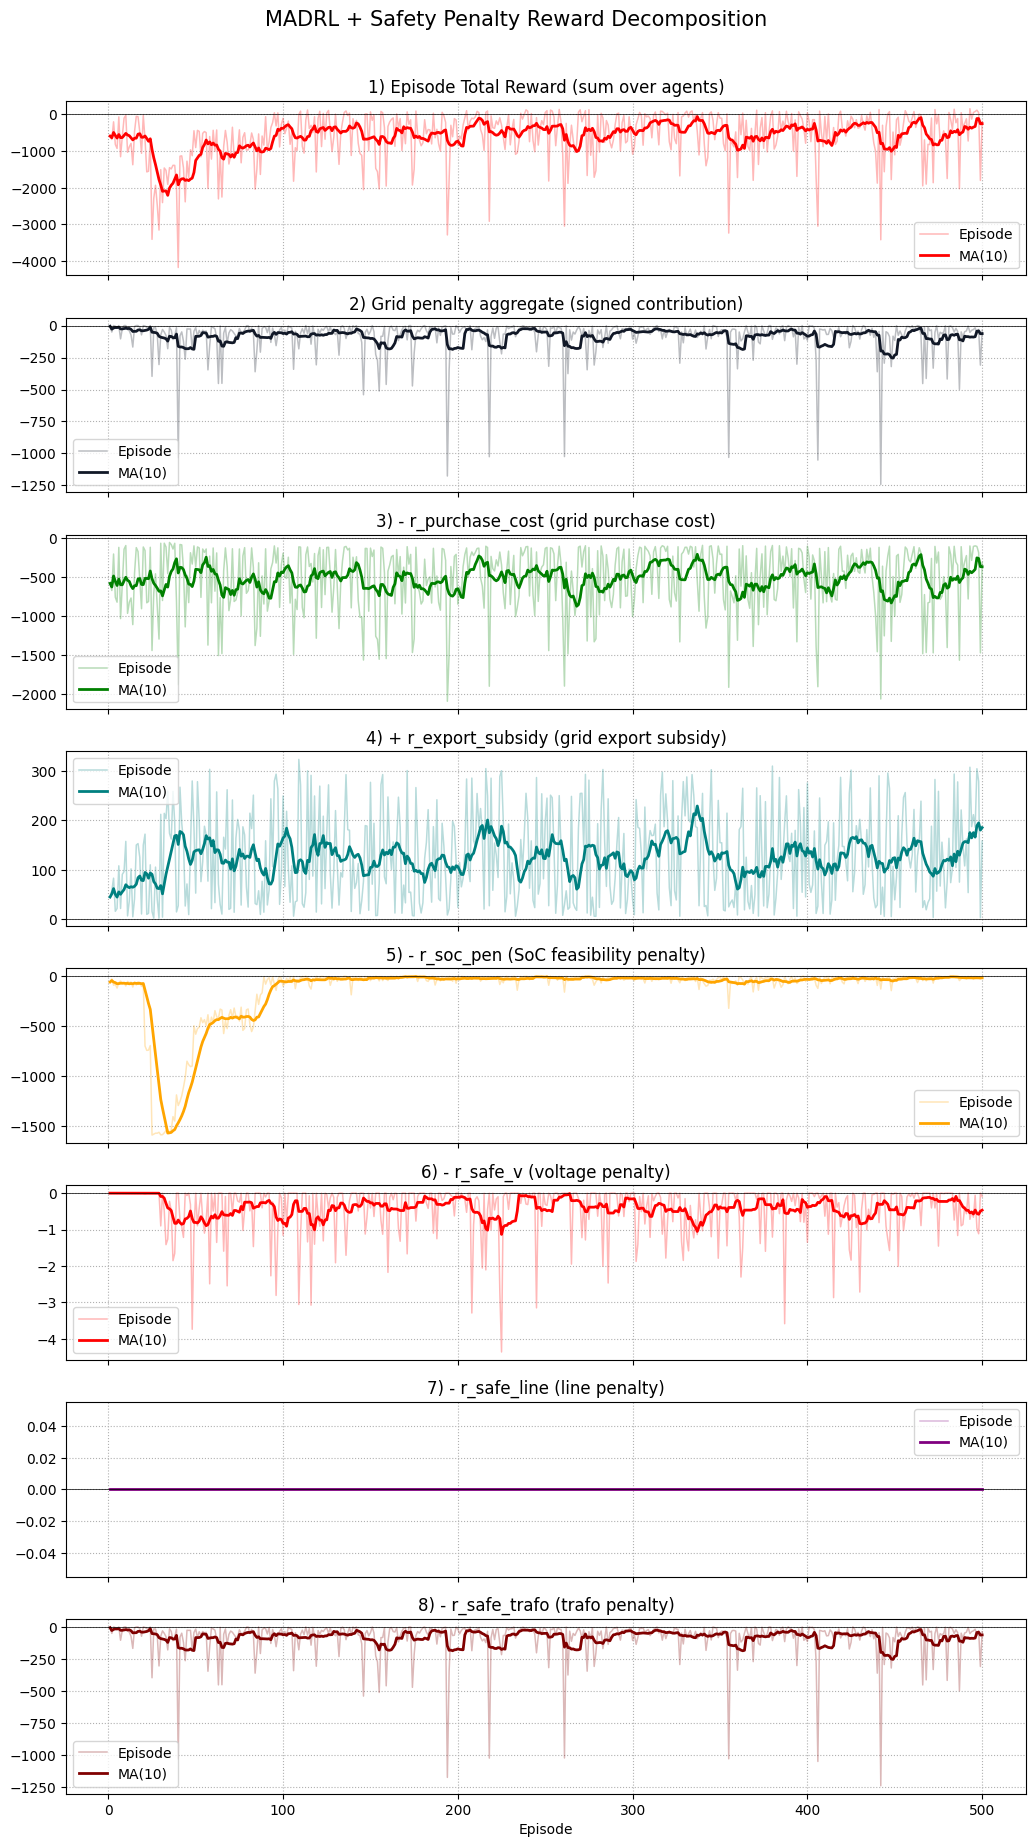

c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-

{'test_start_date': '2020-06-01',
 'test_end_date': '2020-06-05',
 'shared_data_signature': '2e2b9d73858260e7'}

,controller,agent_profile,purchase_cost,export_subsidy,objective_total
0,MADRL + Safety Penalty,SFH12,19.497958,52.274182,-14.551005
1,MADRL + Safety Penalty,SFH14,18.475728,56.607539,-30.342095
2,MADRL + Safety Penalty,SFH16,7.386242,58.064152,-36.651400
3,MADRL + Safety Penalty,SFH18,16.708977,54.291905,-29.338591
4,MADRL + Safety Penalty,SFH20,34.655554,29.758934,40.294117


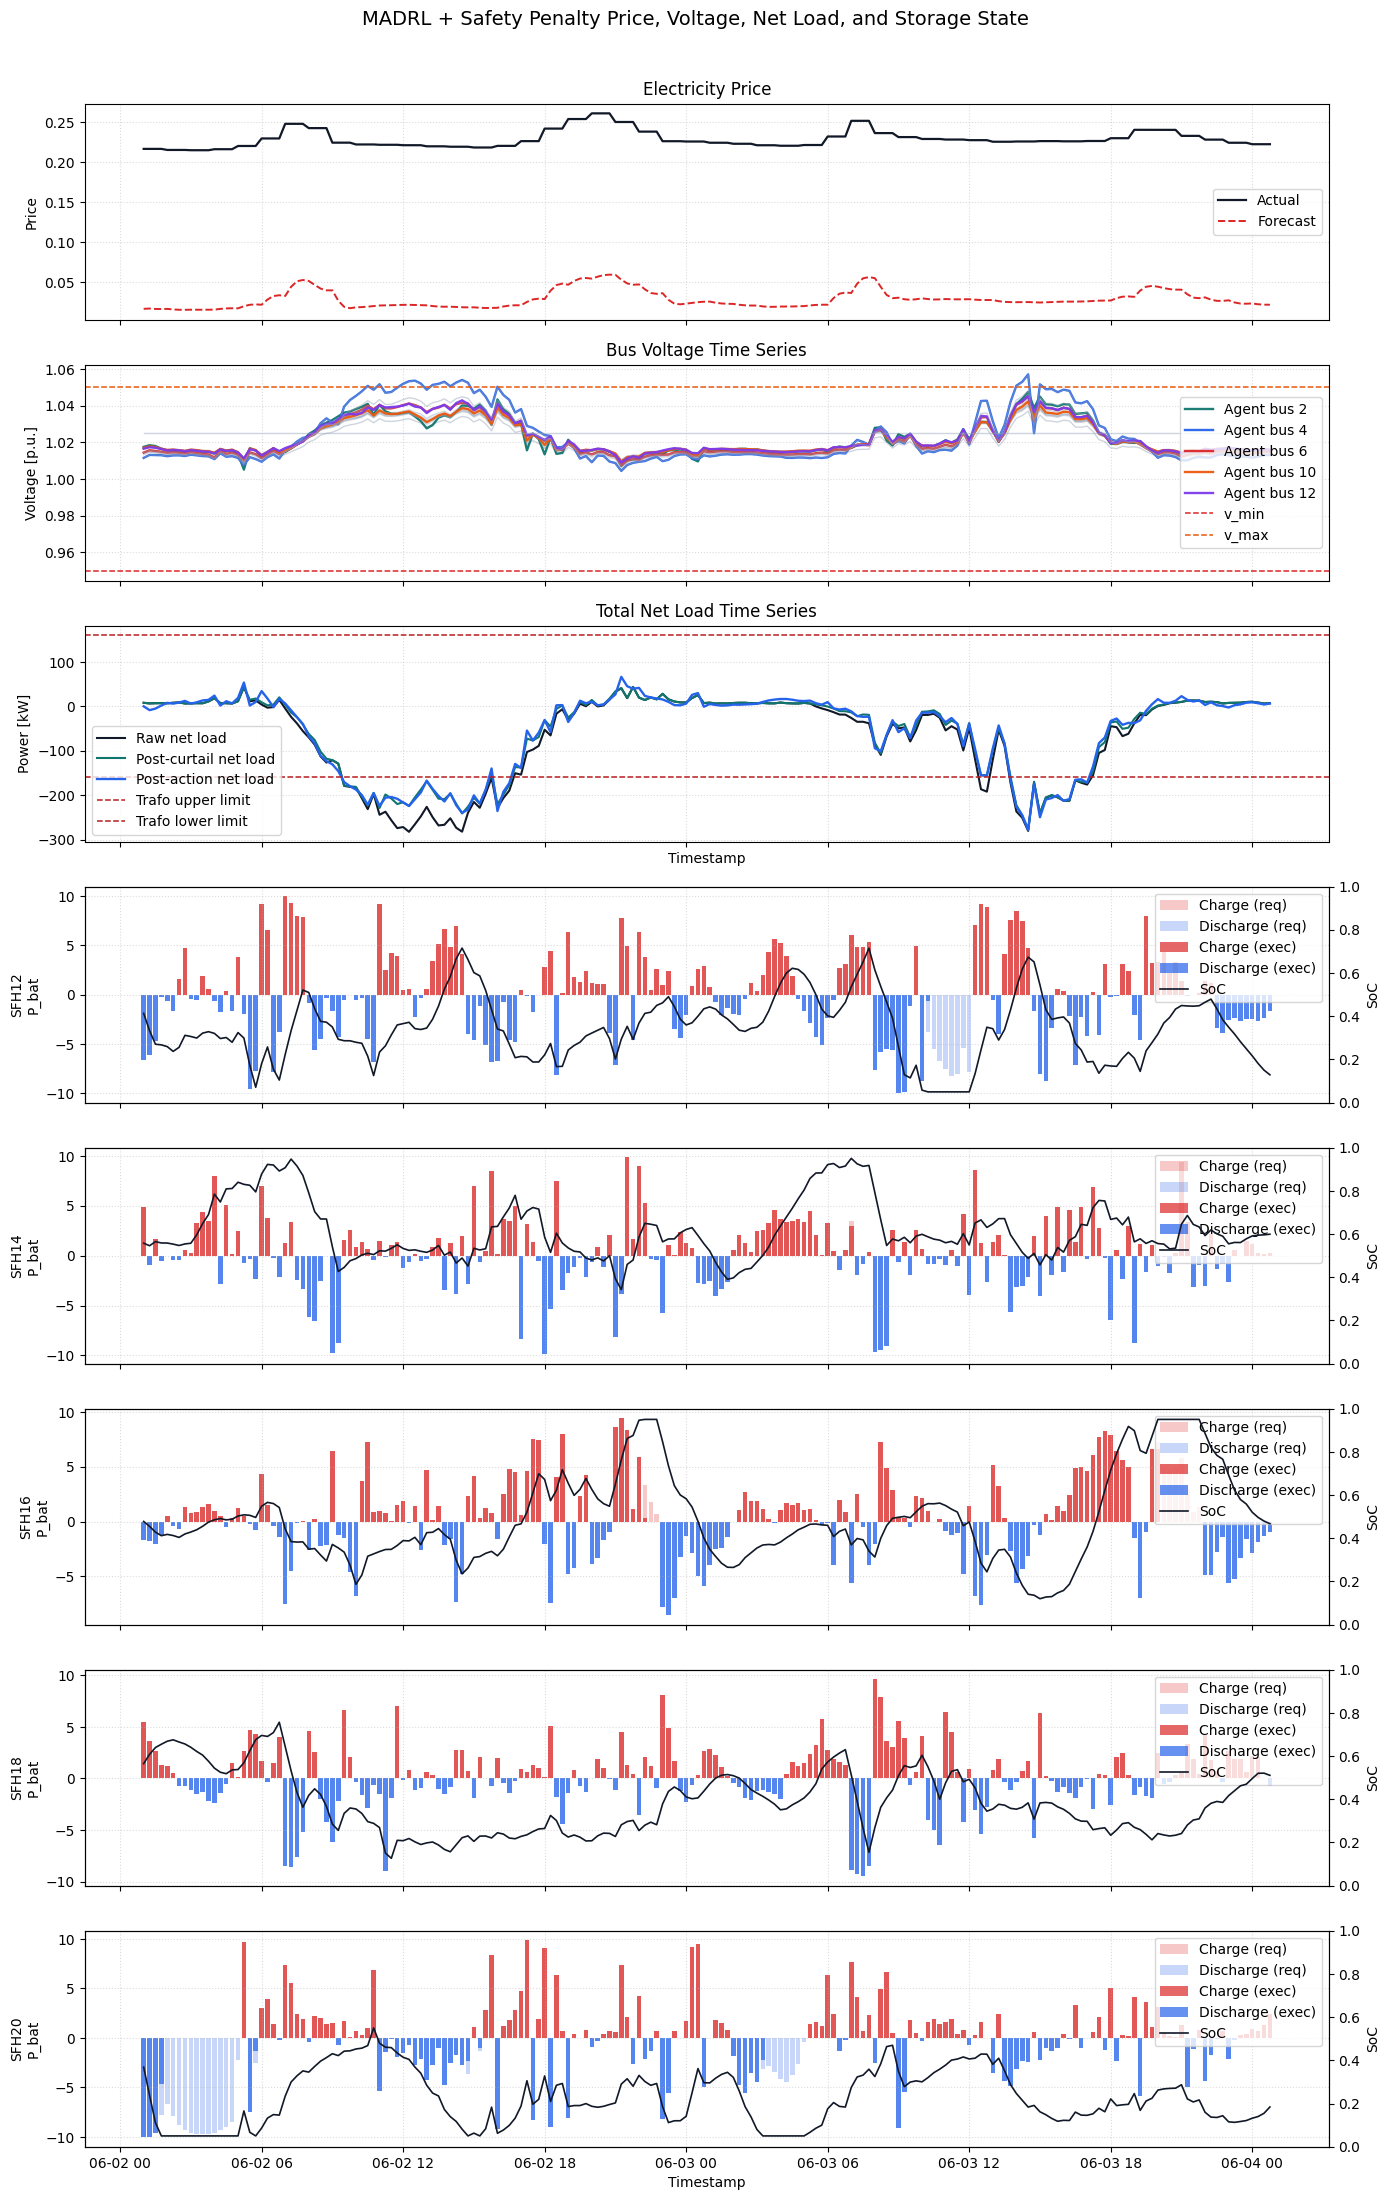

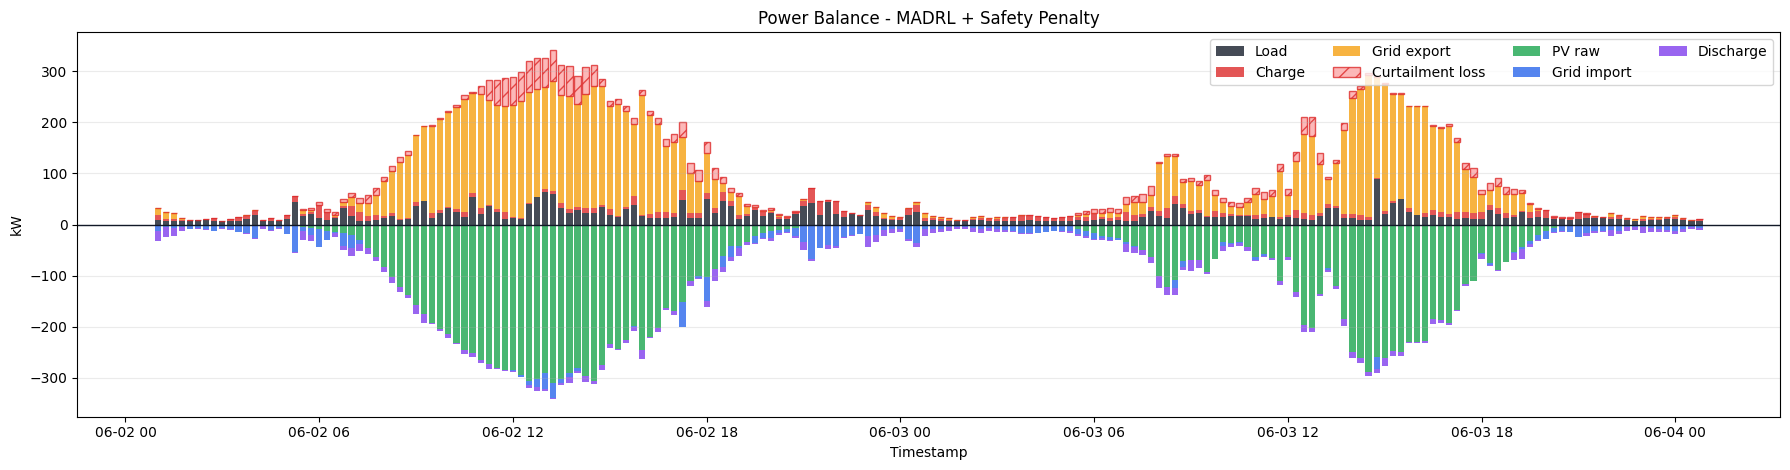

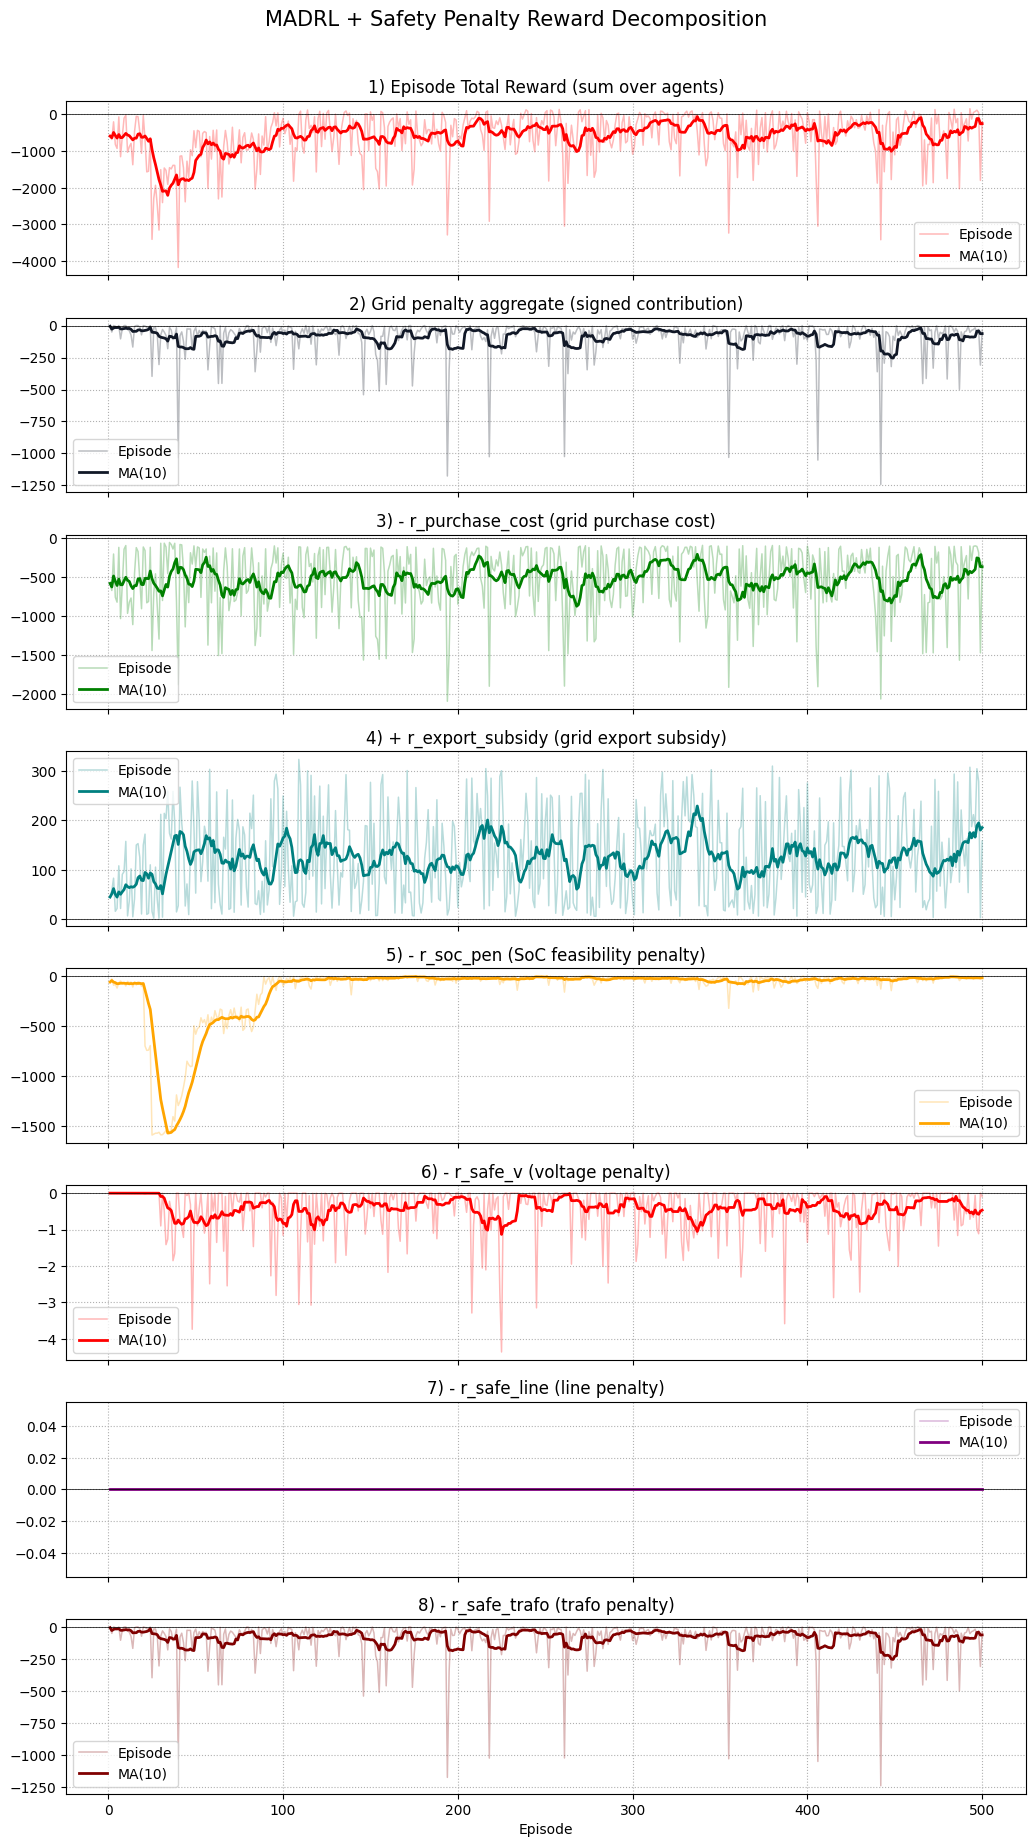

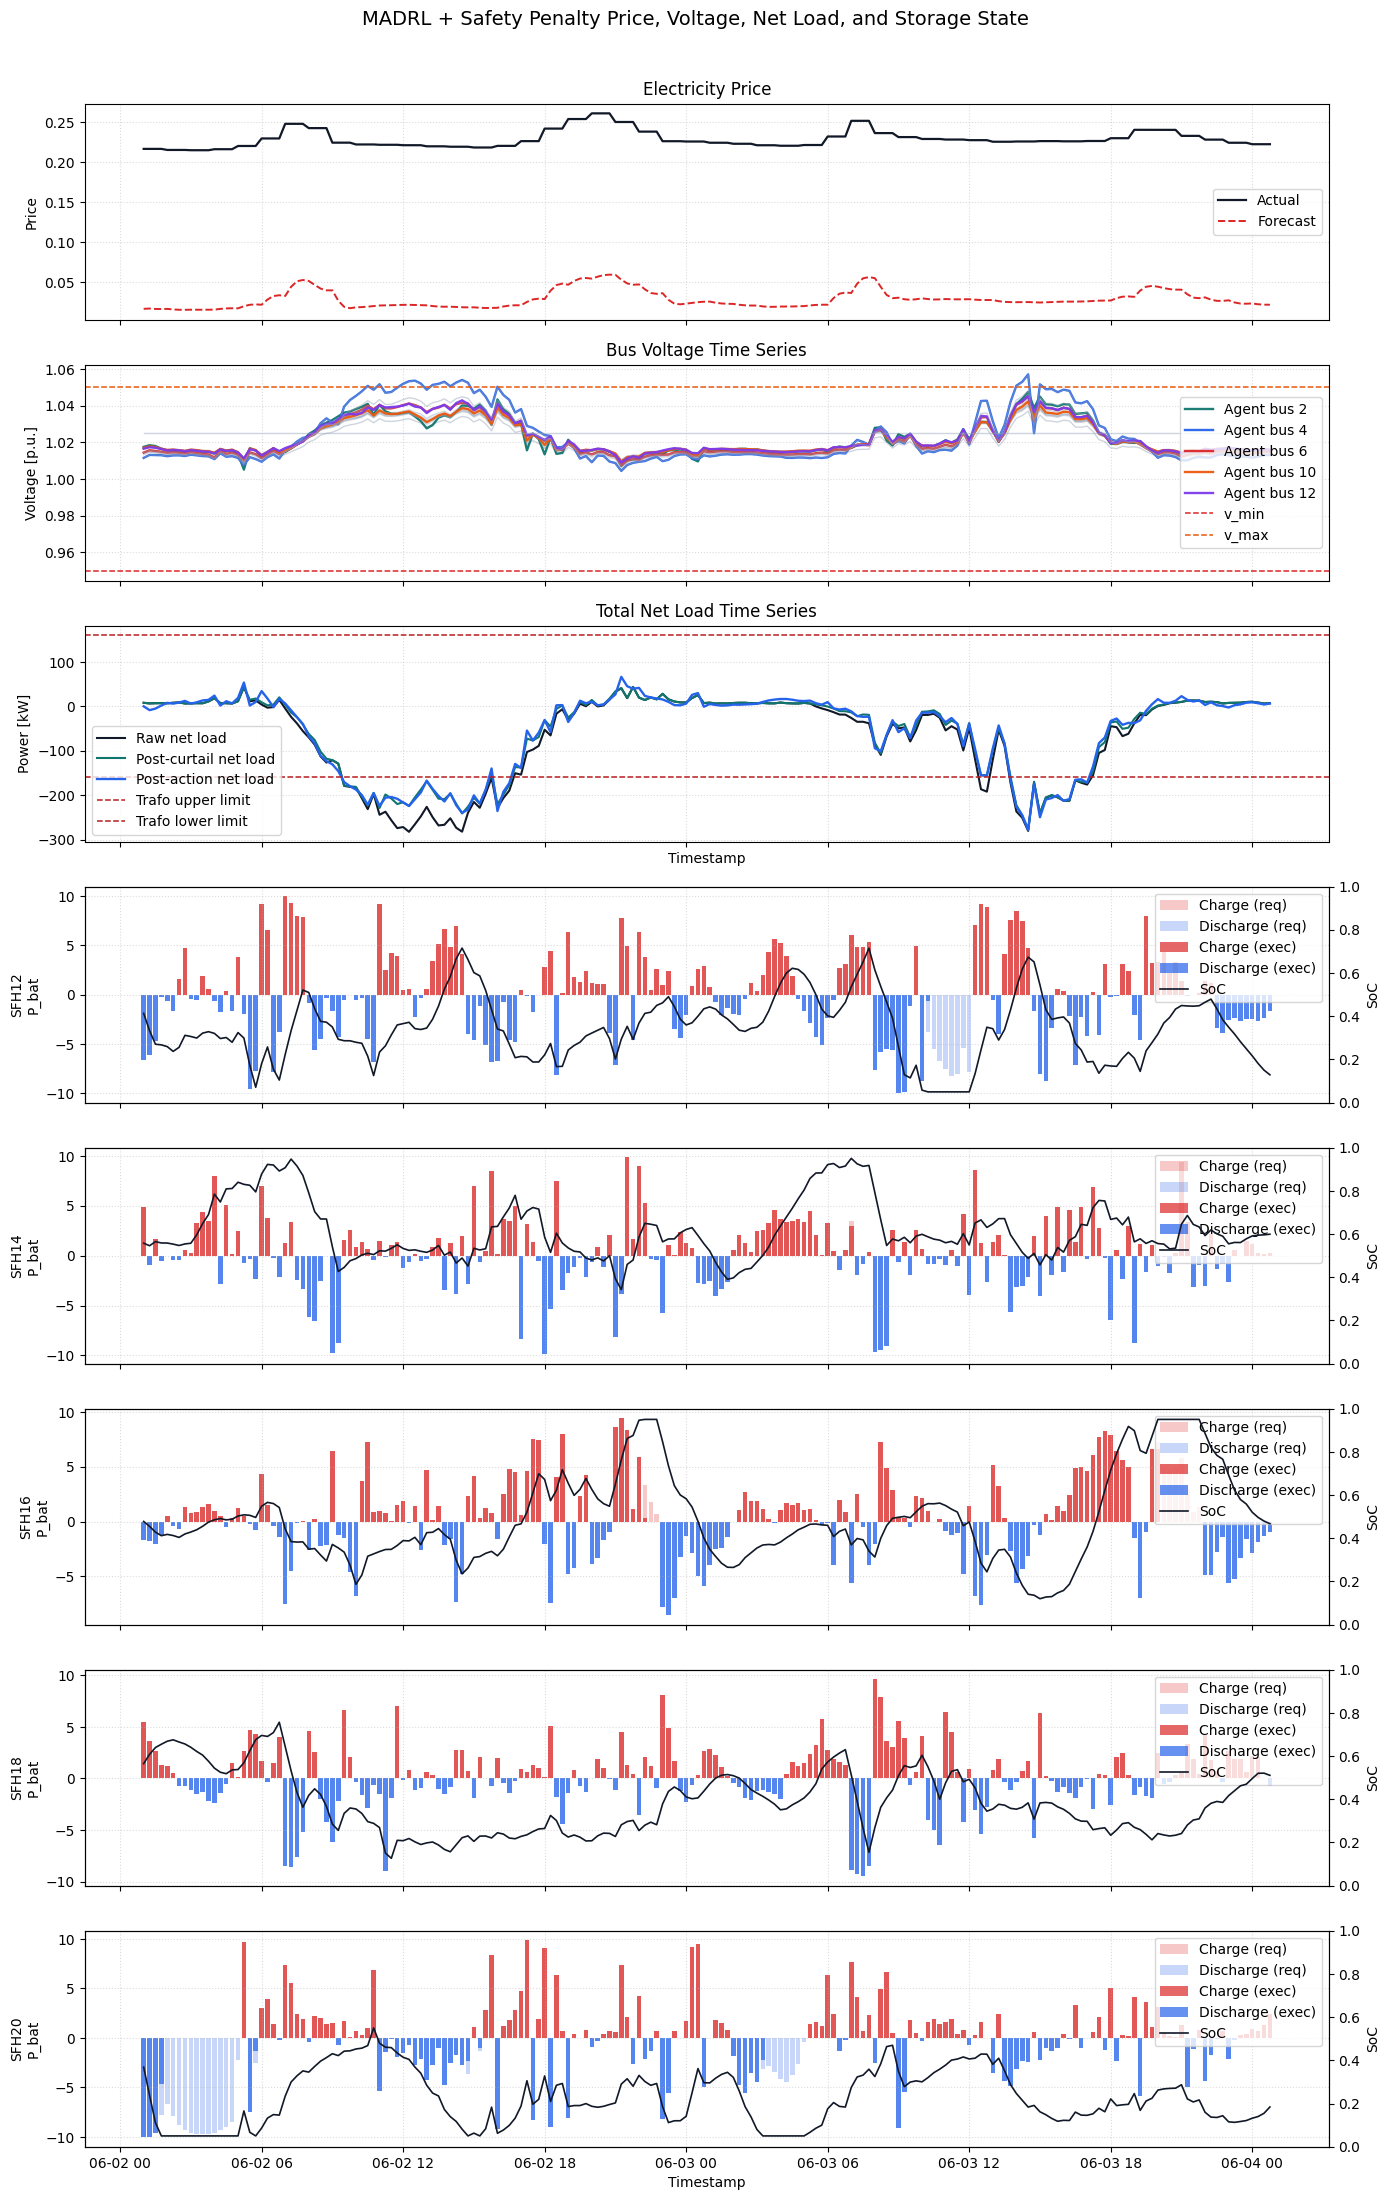

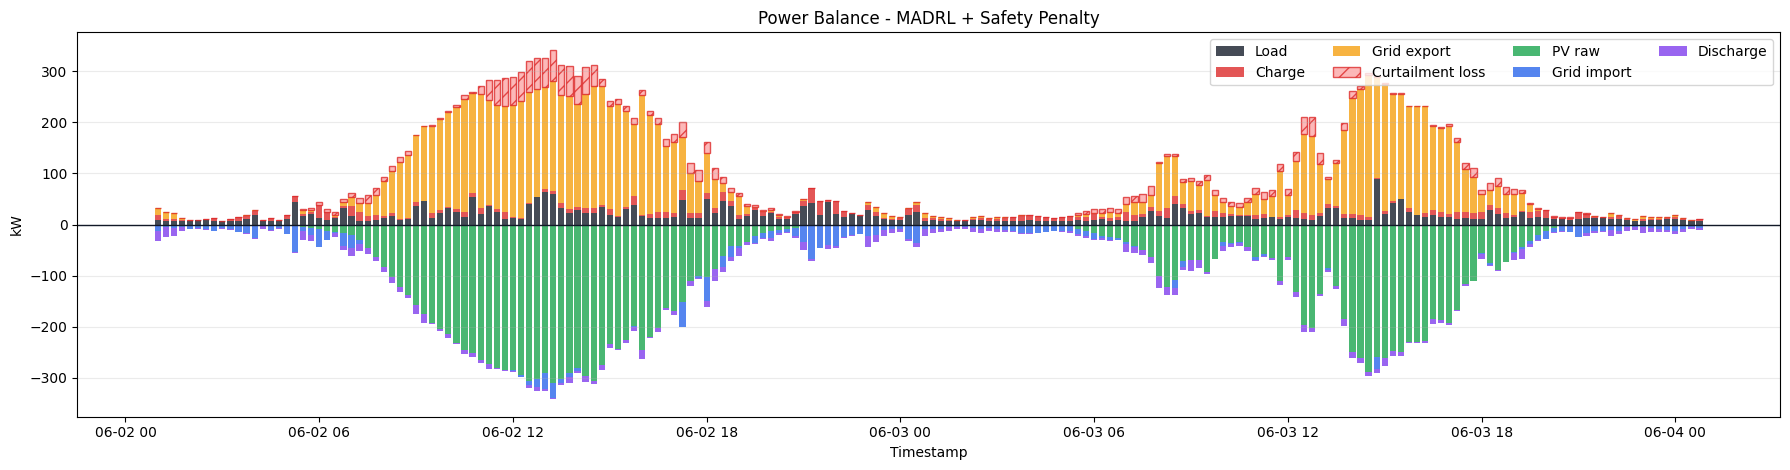

In [6]:
display(
    plot_reward_decomposition(
        reward_summary=train_result["reward_summary_path"],
        title=f"{display_label} Reward Decomposition",
        window=10,
    )
)

rollout = collect_madrl_rollout(
    rollout_cfg,
    model_root=train_result["model_root"],
    algorithm=algorithm,
    experiment_name=experiment_name,
    checkpoint_root=CHECKPOINT_ROOT,
    label=display_label,
)
display(
    {
        "test_start_date": normalized_test_start_date,
        "test_end_date": normalized_test_end_date,
        "shared_data_signature": getattr(rollout_cfg.runtime, "shared_data_signature", None),
    }
)
display(rollout.summary)
display(
    plot_voltage_and_net_load_dashboard(
        rollout,
        title=f"{display_label} Price, Voltage, Net Load, and Storage State",
    )
)
display(plot_power_balance_comparison(rollout))


In [7]:
# Optional deep-dive dashboard for forecast quality and per-agent detail.
if False:
    display(plot_rollout_dashboard(rollout))
